In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:

# 1. Set the path to your folder with the CSV files
folder_path = 'data/speeches2014-2024/'  # <- change this to your folder path

# 2. Read all CSVs into a list of DataFrames
dfs = []
for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(folder_path, file))
        dfs.append(df)
display(df.head())

,file_id,speaker_name,speaker_party,speech_text,jaar,date,kamer,category,title,document_number,url,meta_url,vergadernummer
0,h-tk-20232024-89-6,De heer Bosma,PVV,De\nAan de orde is de Wijziging Omgevingswet e...,2023-2024,2024-06-26,tk,handelingen,6 Wet uitvoering verordening ontbossingsvrije ...,NaN,https://zoek.officielebekendmakingen.nl/h-tk-2...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 89, item 6"
1,h-tk-20232024-89-6,De heer Bosma,PVV,De\nAls eerste geef ik graag het woord aan mev...,2023-2024,2024-06-26,tk,handelingen,6 Wet uitvoering verordening ontbossingsvrije ...,NaN,https://zoek.officielebekendmakingen.nl/h-tk-2...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 89, item 6"
2,h-tk-20232024-89-6,Mevrouw Hertzberger,NSC,Mevrouw\nVoorzitter. Deze wet voor de implemen...,2023-2024,2024-06-26,tk,handelingen,6 Wet uitvoering verordening ontbossingsvrije ...,NaN,https://zoek.officielebekendmakingen.nl/h-tk-2...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 89, item 6"
3,h-tk-20232024-89-6,De heer Bosma,PVV,De\nNeem even een pauze. Mevrouw Bromet praat ...,2023-2024,2024-06-26,tk,handelingen,6 Wet uitvoering verordening ontbossingsvrije ...,NaN,https://zoek.officielebekendmakingen.nl/h-tk-2...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 89, item 6"
4,h-tk-20232024-89-6,Mevrouw Bromet,GroenLinks-PvdA,"Mevrouw\nIk verstond het niet, maar dat geeft ...",2023-2024,2024-06-26,tk,handelingen,6 Wet uitvoering verordening ontbossingsvrije ...,NaN,https://zoek.officielebekendmakingen.nl/h-tk-2...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 89, item 6"


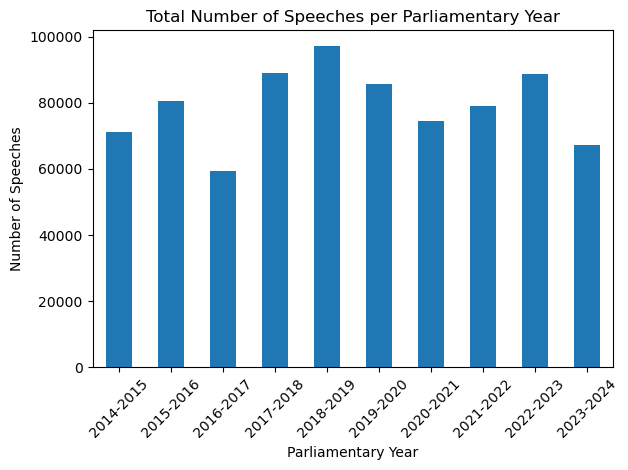

All speeches in total: 792499
Average number of speeches per session day: 743.43


In [8]:
# 3. Combine into one big DataFrame
all_speeches = pd.concat(dfs, ignore_index=True)

# 4. Plot total speeches per year
speech_counts = all_speeches['jaar'].value_counts().sort_index()
speech_counts.plot(kind='bar')
plt.xlabel('Parliamentary Year')
plt.ylabel('Number of Speeches')
plt.title('Total Number of Speeches per Parliamentary Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate average speeches per session day
session_day_counts = all_speeches.groupby('date').size()
average_per_day = session_day_counts.mean()

print(f'All speeches in total: {len(all_speeches)}')
print(f"Average number of speeches per session day: {average_per_day:.2f}")


/tmp/ipykernel_17179/3282409108.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(yearly_grouped.values, labels=yearly_grouped.index)


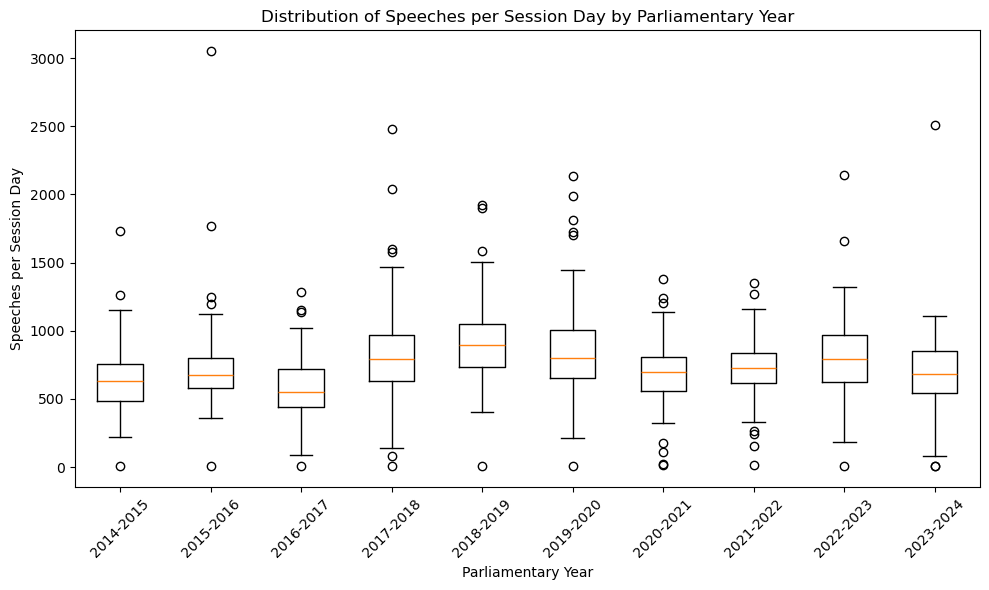

In [7]:
# Ensure 'date' is in datetime format
all_speeches['date'] = pd.to_datetime(all_speeches['date'])

# Group by date to count speeches per session day
daily_counts = all_speeches.groupby(['jaar', 'date']).size().reset_index(name='speech_count')

# Pivot to prepare for boxplot
yearly_grouped = daily_counts.groupby('jaar')['speech_count'].apply(list)

# Plot boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(yearly_grouped.values, labels=yearly_grouped.index)
plt.xlabel('Parliamentary Year')
plt.ylabel('Speeches per Session Day')
plt.title('Distribution of Speeches per Session Day by Parliamentary Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cost calculation
Total entries: 792499

deepseek-r1:8b metrix: 
n tests: 50
Duration (s): 672.43
Cost ($): 0.15
Accuracy: 72.00%
Unparsed : 0
Electricity Usage (W): 45205.44


In [13]:
def energy_to_car_distance(joules):
    MJ_per_100km = 8 * 34.2  # 8L/100km * 34.2 MJ/L
    km = (joules / 1e6) / MJ_per_100km * 100
    return km

def energy_to_flight_distance(joules):
    MJ_per_km = 2.5  # per passenger
    km = (joules / 1e6) / MJ_per_km
    return km

# Estimate side power cost. 
# 
# Estimate pue as 1.3 bc modal is a hyper efficant provider
# Estimate 50% extra on environment/side-quest dependencies
def estimate_true_energy(gpu_kj, cpu_to_gpu_ratio=0.5, pue=1.3):
    cpu_kj = gpu_kj * cpu_to_gpu_ratio
    total_kj = (gpu_kj + cpu_kj) * pue
    return total_kj



In [14]:
def get_test_estimation(sample_size):
    n_test = 50 
    duration = 672.43 * sample_size/n_test
    cost = 0.15 * sample_size/n_test
    energy = 45205.44 * sample_size/n_test

    energy = estimate_true_energy(energy)

    print(f"Approximately, for {sample_size} samples there is a total of {duration} gpu seconds, thats {cost} $ and takes about {energy} joules")
    print(f"Thats about {energy_to_car_distance(energy)} km by an average car or {energy_to_flight_distance(energy)} km by plane")

get_test_estimation(792499)

get_test_estimation(743)

Approximately, for 792499 samples there is a total of 10658002.051399998 gpu seconds, thats 2377.497 $ and takes about 1397185373.7878401 joules
Thats about 510.6671687821052 km by an average car or 558.874149515136 km by plane
Approximately, for 743 samples there is a total of 9992.309799999999 gpu seconds, thats 2.229 $ and takes about 1309918.0348800002 joules
Thats about 0.47877121157894736 km by an average car or 0.5239672139520001 km by plane


## Sampling
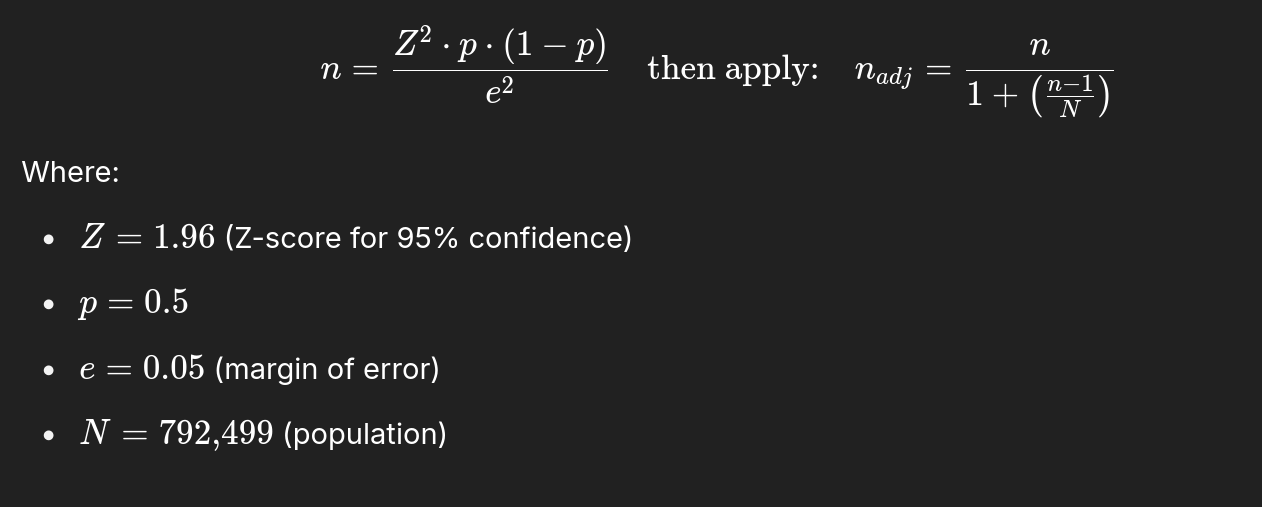

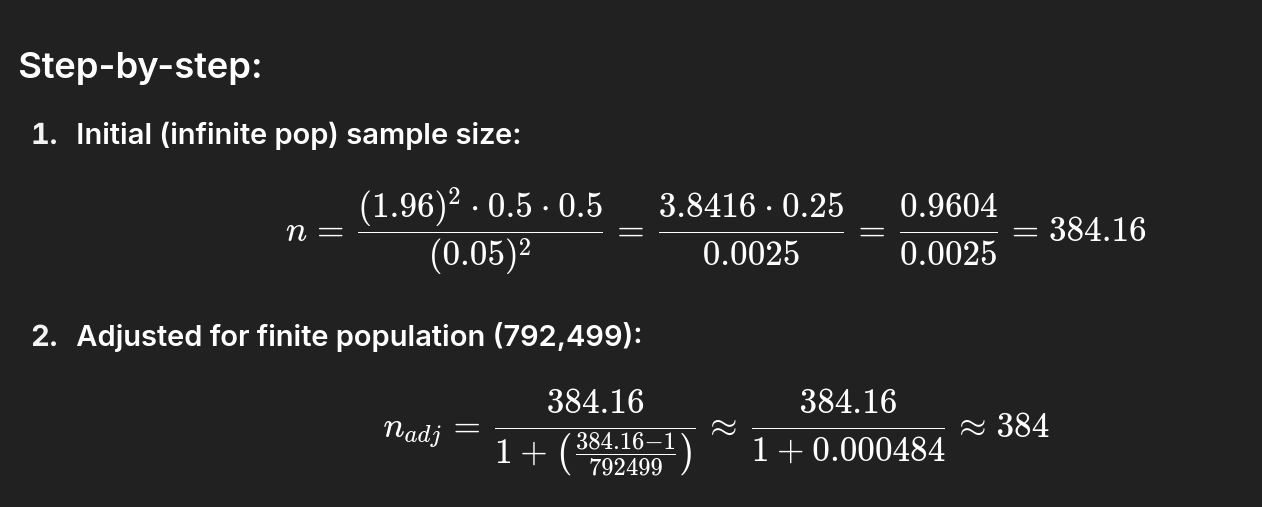

In [15]:
get_test_estimation(384)

Approximately, for 384 samples there is a total of 5164.2624 gpu seconds, thats 1.152 $ and takes about 676996.66944 joules
Thats about 0.2474403031578947 km by an average car or 0.270798667776 km by plane


In [ ]:


# Parameters
Z = 1.96           # Z-score for 95% confidence
p = 0.5            # Population proportion
e = 0.05           # Margin of error

# Infinite population sample size
n0 = (Z**2 * p * (1 - p)) / (e**2)

# Generate a range of population sizes
population_sizes = np.linspace(1000, 1_000_000, 500)
sample_sizes = n0 / (1 + ((n0 - 1) / population_sizes))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(population_sizes, sample_sizes, label='Sample Size')
plt.axhline(y=n0, color='gray', linestyle='--', label='Infinite Population Sample Size')
plt.title('Population Size vs Required Sample Size\n(95% Confidence, 5% Margin of Error)')
plt.xlabel('Population Size')
plt.ylabel('Sample Size')
plt.grid(True)
plt.legend()
plt.tight_layout()

NameError: name 'plt' is not defined